<a href="https://colab.research.google.com/github/realclovisworld/Neural_Networks/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 3

**(QN)** Design and implement a CNN model with 2 layers of convolution to classify multi category image datasets. Record the accuracy corresponding to the number of epochs. Use the MNIST,CIFAR-10 datasets

# **STEPS**

1. Import python liblaries for building and training the CNN
2. Load the MNIST dataset into testing and training
3. Reshape and normalise (divde by 255) input data
4. Define the architecture of the CNN model using Keras's Sequential API.
5. Compile the model
6. Train the model
7. Evaluate the model on the test dataset



In [ ]:
#import packages
import keras
from keras.datasets import mnist
from keras.layers import Dense,Activation,Flatten,Conv2D,MaxPooling2D
from keras.models import Sequential
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#load dataset
(train_X,train_Y),(test_X,test_Y)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#preprocessing of the data
train_X = train_X.reshape(-1,28,28,1)
test_X = test_X.reshape(-1,28,28,1)
train_X.shape

train_X = train_X.astype('float32')/255
test_X = test_X.astype('float32')/255

train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

In [ ]:
model = Sequential()

model.add(Conv2D(64, (3, 3), input_shape=(28, 28, 1)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Dense(10))
model.add(Activation('softmax'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,682 (549.54 KB)

 Trainable params: 140,682 (549.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compile the model
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(),metrics=['accuracy'])

In [ ]:
model.fit(train_X,train_Y_one_hot,batch_size=64,epochs=5)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 87s 91ms/step - accuracy: 0.9540 - loss: 0.1487
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 134s 83ms/step - accuracy: 0.9840 - loss: 0.0509
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.9887 - loss: 0.0369
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 82ms/step - accuracy: 0.9908 - loss: 0.0285
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - accuracy: 0.9926 - loss: 0.0233


In [ ]:
#Model evaluation
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9890 - loss: 0.0319
Test loss: 0.031937990337610245
Test accuracy: 0.9890000224113464


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
7


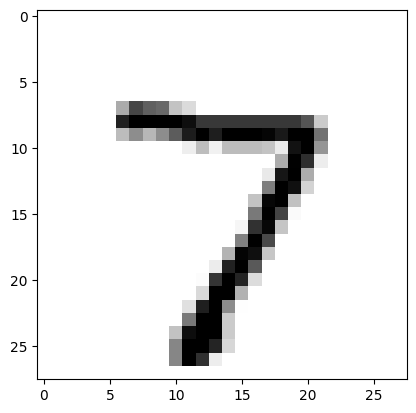

In [ ]:
#Model prediction
predictions = model.predict(test_X)
print(np.argmax(np.round(predictions[0])))
plt.imshow(test_X[0].reshape(28,28),cmap = plt.cm.binary)
plt.show()

In [ ]:
#Train model on 10 Epochs
model.fit(train_X,train_Y_one_hot,batch_size=64,epochs=10)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 74s 79ms/step - accuracy: 0.9935 - loss: 0.0189
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.9946 - loss: 0.0159
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.9963 - loss: 0.0122
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 80ms/step - accuracy: 0.9964 - loss: 0.0118
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 81ms/step - accuracy: 0.9965 - loss: 0.0107
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9967 - loss: 0.0094
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 82ms/step - accuracy: 0.9976 - loss: 0.0074
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 82ms/step - accuracy: 0.9973 - loss: 0.0084
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.9978 - loss: 0.0063
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 83ms/step - accuracy: 0.9973 - loss: 0.0079


In [ ]:
#Accuracy score (10 epochs)
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9891 - loss: 0.0437
Test loss: 0.043708547949790955
Test accuracy: 0.9890999794006348


# ACCURACY SCORE
1. 5 Epochs = accuracy: 0.9926 - loss: 0.0233
2. 10 Epochs = 0.9973 - loss: 0.0079